In [43]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Handle Data Types and Missing Values
# TotalCharges is currently an object because of blank spaces. Convert to numeric.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))

# Check for missing values
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Since only 11 rows are missing (out of 7043), it's safe to drop them.
df.dropna(inplace=True)

# 3. Drop useless columns
# customerID adds no predictive value
df.drop('customerID', axis=1, inplace=True)

# 4. Feature Engineering: Encoding Categorical Variables
# We will map 'Yes'/'No' to 1/0, and use one-hot encoding for multi-category features
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Select remaining categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Data Preprocessing Complete. New shape:", df_encoded.shape)

Missing values in TotalCharges: 11
Data Preprocessing Complete. New shape: (7032, 31)


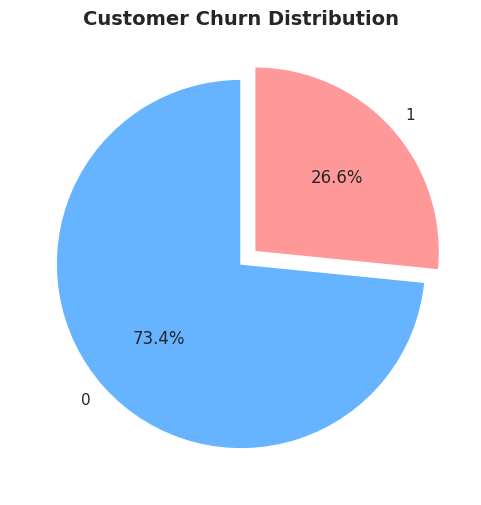

In [44]:
# Target Variable Distribution
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1))
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.show()

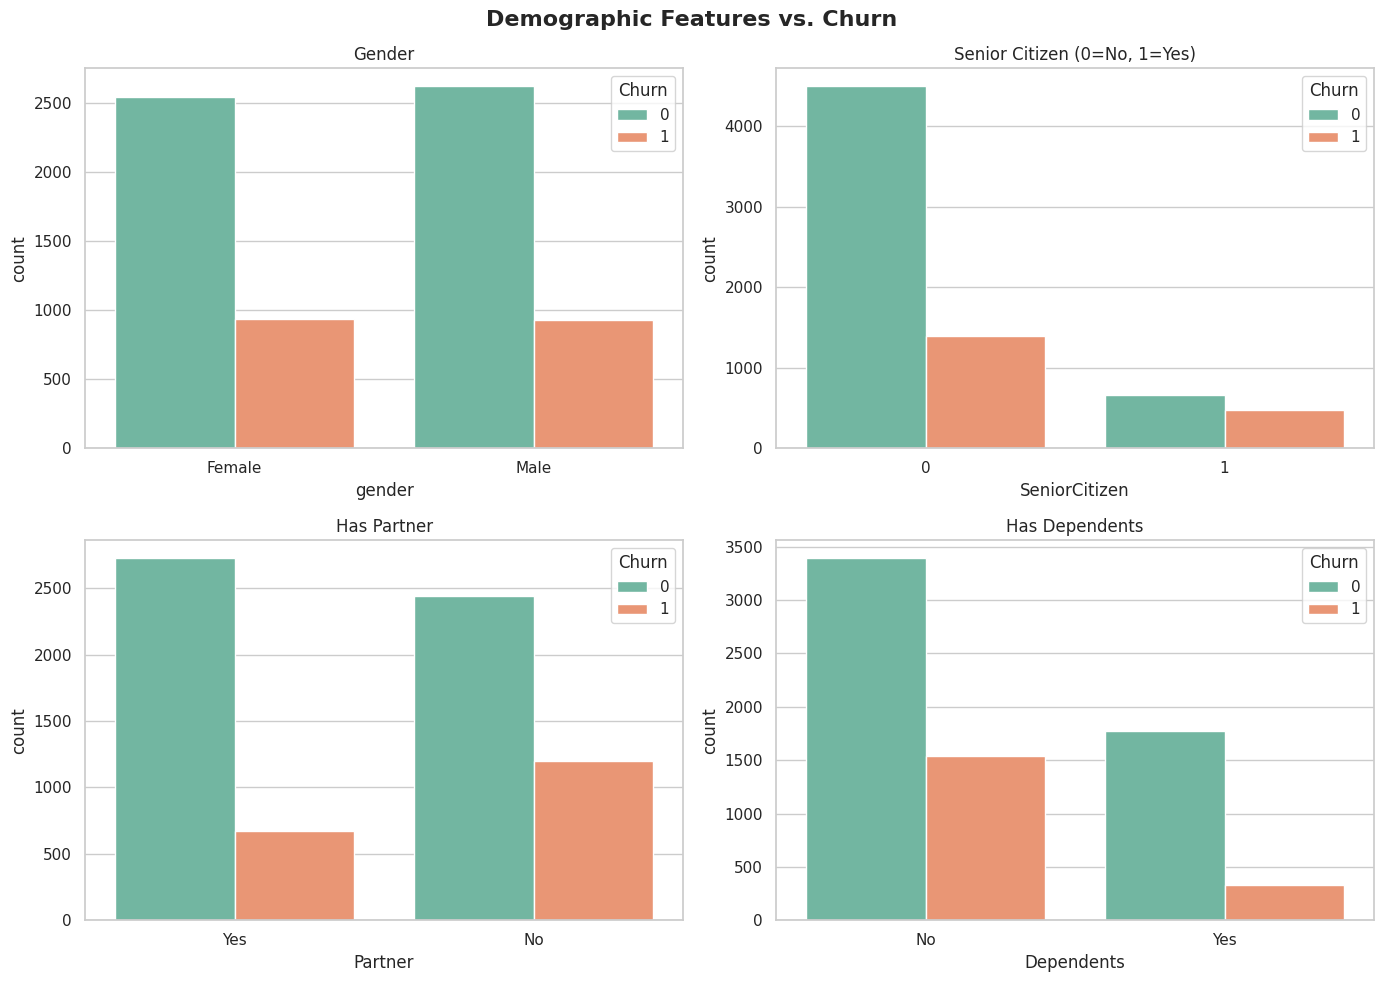

In [45]:
# Set up a 2x2 grid for Demographic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Demographic Features vs. Churn', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='gender', hue='Churn', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Gender')

sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Senior Citizen (0=No, 1=Yes)')

sns.countplot(data=df, x='Partner', hue='Churn', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Has Partner')

sns.countplot(data=df, x='Dependents', hue='Churn', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Has Dependents')

plt.tight_layout()
plt.show()

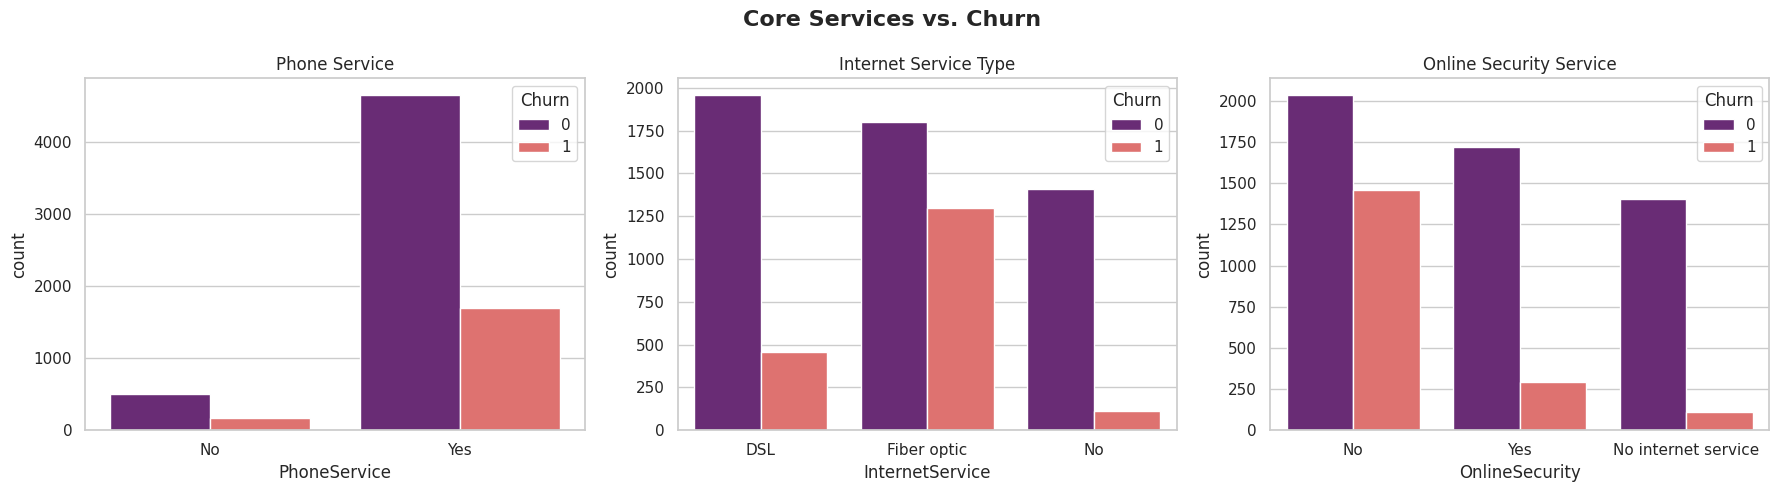

In [46]:
# Visualizing core services
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Core Services vs. Churn', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='PhoneService', hue='Churn', palette='magma', ax=axes[0])
axes[0].set_title('Phone Service')

sns.countplot(data=df, x='InternetService', hue='Churn', palette='magma', ax=axes[1])
axes[1].set_title('Internet Service Type')

sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette='magma', ax=axes[2])
axes[2].set_title('Online Security Service')

plt.tight_layout()
plt.show()

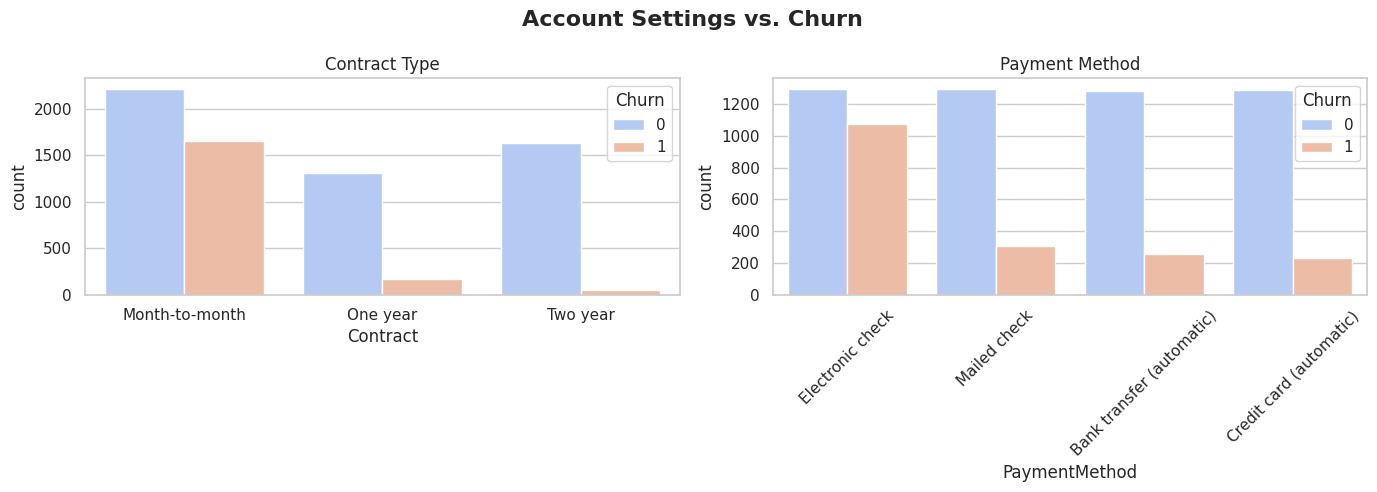

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Account Settings vs. Churn', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='Contract', hue='Churn', palette='coolwarm', ax=axes[0])
axes[0].set_title('Contract Type')

sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='coolwarm', ax=axes[1])
axes[1].set_title('Payment Method')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_15579/2546353389.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', palette='muted', ax=axes[2])


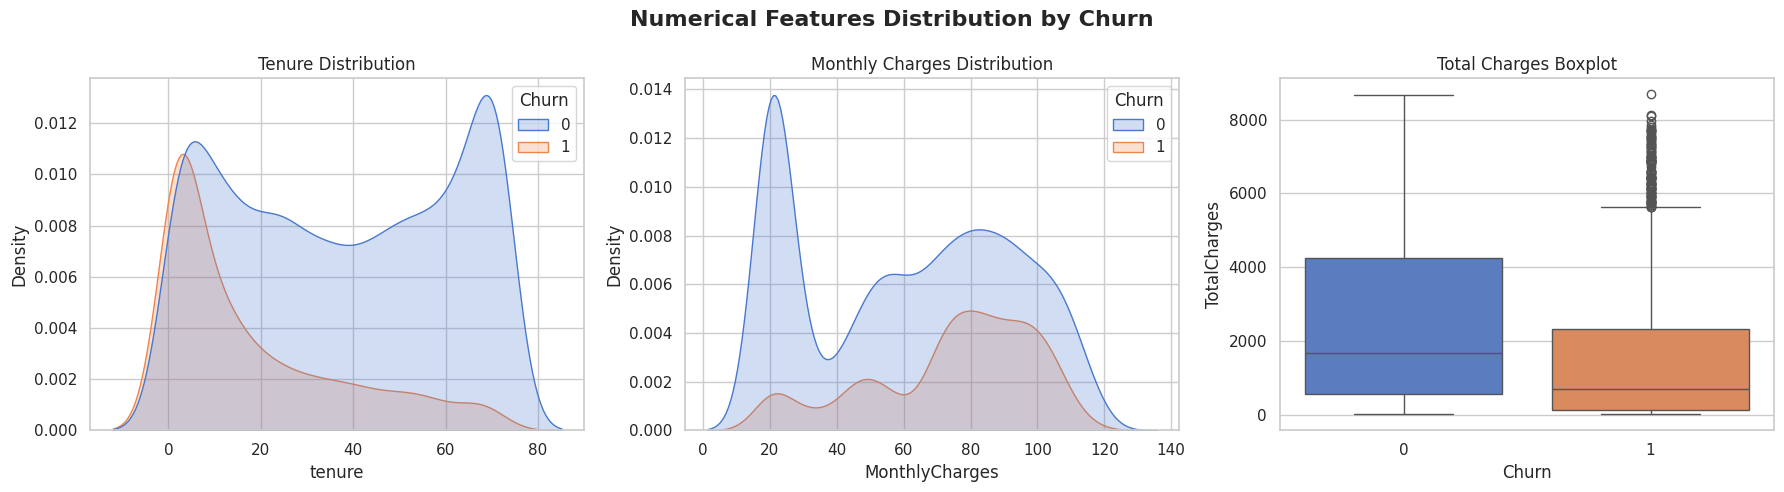

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Numerical Features Distribution by Churn', fontsize=16, fontweight='bold')

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='muted', ax=axes[0])
axes[0].set_title('Tenure Distribution')

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='muted', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution')

sns.boxplot(data=df, x='Churn', y='TotalCharges', palette='muted', ax=axes[2])
axes[2].set_title('Total Charges Boxplot')

plt.tight_layout()
plt.show()

Correlation with Churn:
Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes        

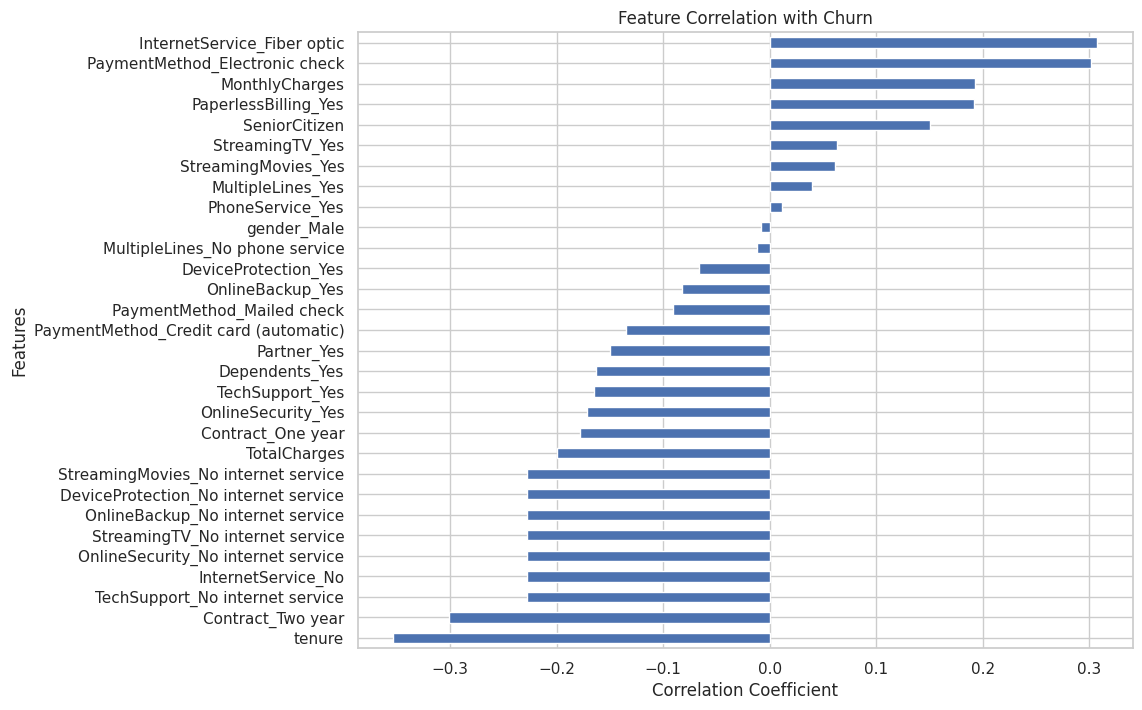

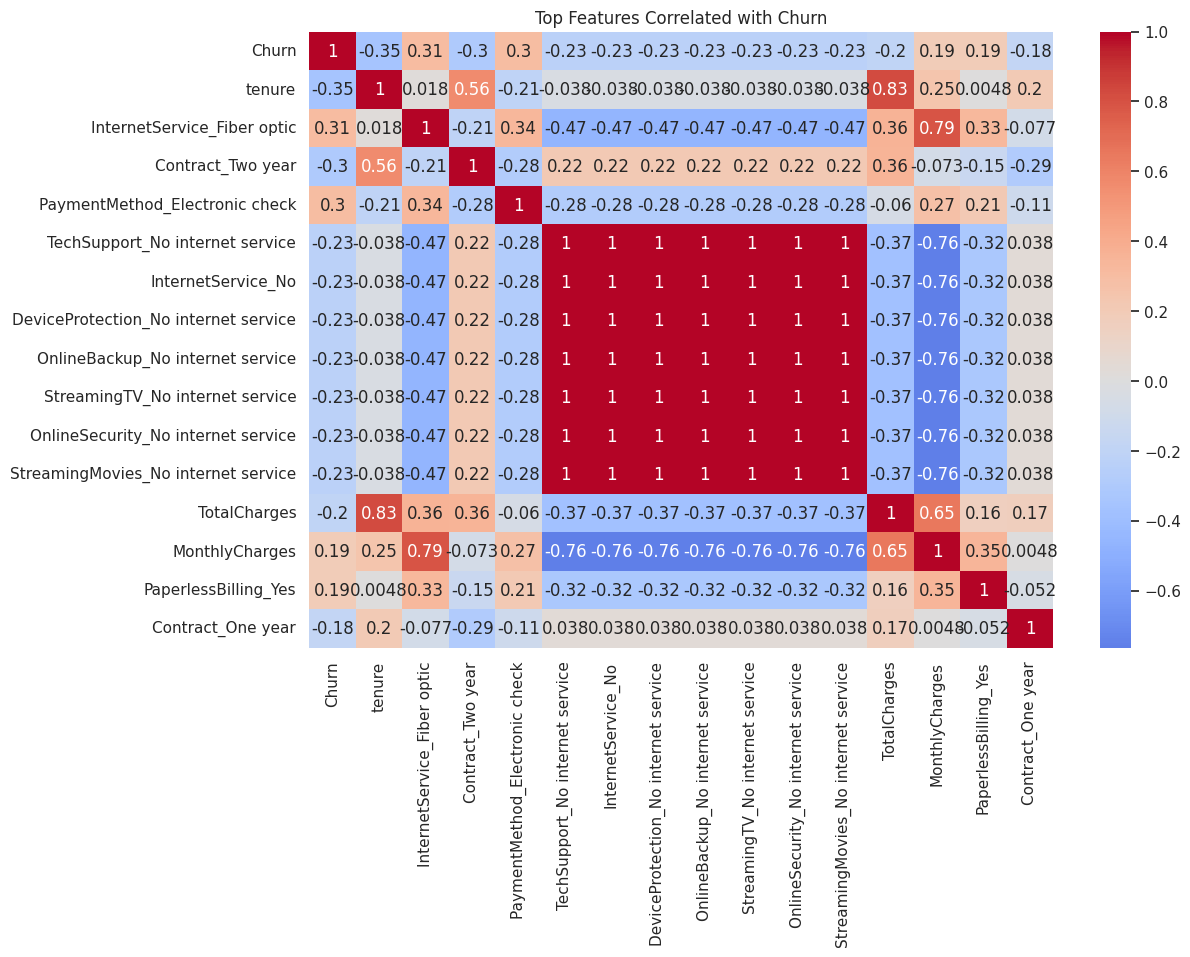

In [49]:
# 5. Correlation Analysis

corr_matrix = df_encoded.corr()

churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

print("Correlation with Churn:")
print(churn_corr)

# Plot correlation with Churn
plt.figure(figsize=(10, 8))
churn_corr.drop('Churn').sort_values().plot(kind='barh')
plt.title("Feature Correlation with Churn")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

# Heatmap for top correlated features
top_corr_features = churn_corr.abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_encoded[top_corr_features].corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Top Features Correlated with Churn")
plt.show()

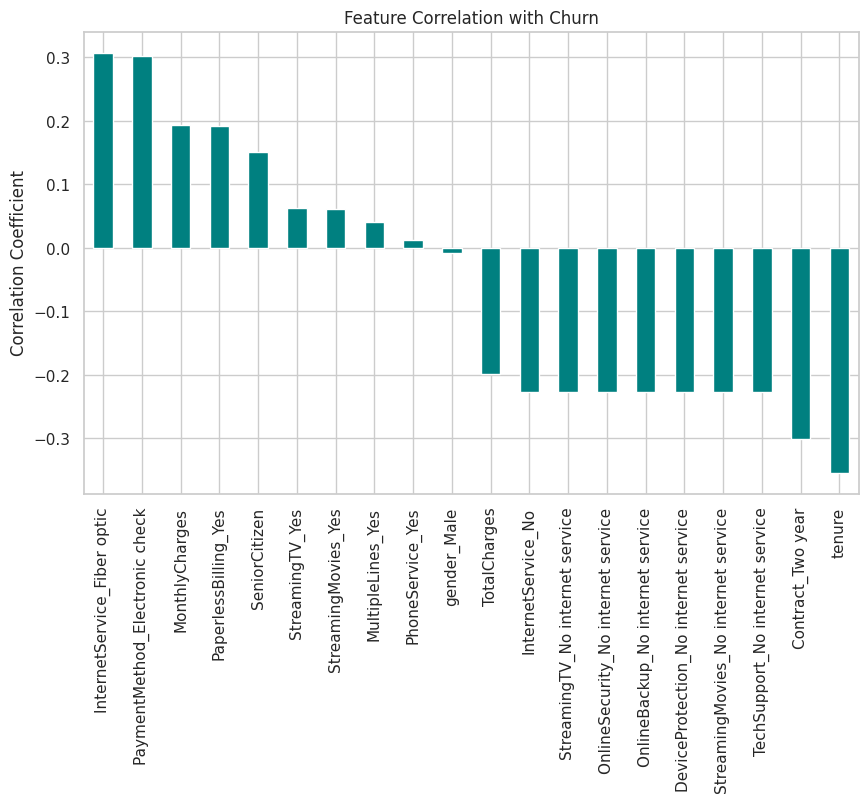

In [50]:
plt.figure(figsize=(10, 6))
# Calculate correlations with Churn
correlations = df_encoded.corr()['Churn'].sort_values(ascending=False)

# Plot top positive and negative correlations (excluding Churn itself)
correlations = correlations.drop('Churn')

# Use pd.concat instead of the deprecated .append()
combined_correlations = pd.concat([correlations.head(10), correlations.tail(10)])
combined_correlations.plot(kind='bar', color='teal')

plt.title('Feature Correlation with Churn')
plt.ylabel('Correlation Coefficient')
plt.show()

In [51]:



# 1. Split Data into X (features) and y (target)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Initialize Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 4. Train and Evaluate Base Models
for name, model in models.items():
    # Use scaled data for Logistic Regression, unscaled is fine for Trees
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.8038
Decision Tree Accuracy: 0.7186
Random Forest Accuracy: 0.7896


In [52]:


# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC-AUC Score: 0.8341


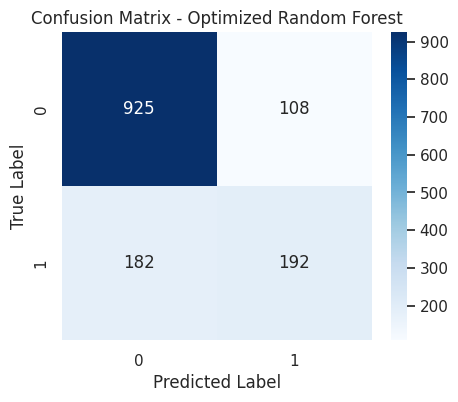

In [53]:


# Make predictions using the optimized Random Forest
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

# 1. Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_best))

# 2. ROC-AUC Score
auc_score = roc_auc_score(y_test, y_prob_best)
print(f"ROC-AUC Score: {auc_score:.4f}")

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Optimized Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
